# Model Interpretability with SHAP and LIME

This notebook demonstrates how to interpret a complex machine learning model (XGBoost) for a credit scoring task. We explore global feature importance, local explanations, and potential biases.

## 1. Imports and Model Training

Generating synthetic credit data and training an XGBoost model.

In [7]:

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Generate synthetic credit data
n_samples = 2000
X = pd.DataFrame({
    'Income': np.random.uniform(20000, 150000, n_samples),
    'Credit_Score': np.random.uniform(300, 850, n_samples),
    'Debt_to_Income_Ratio': np.random.uniform(0.1, 0.7, n_samples),
    'Employment_Years': np.random.uniform(0, 40, n_samples),
    'Gender_Proxy': np.random.binomial(1, 0.5, n_samples)  # For fairness analysis
})

# Define a decision rule with some noise
y = (0.5 * X['Credit_Score'] / 850 + 0.3 * X['Income'] / 150000 - 0.2 * X['Debt_to_Income_Ratio'] + 0.1 * np.random.normal(0, 1, n_samples)) > 0.4
y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost
model = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

print(f"Model trained. Accuracy: {model.score(X_test, y_test):.4f}")


Model trained. Accuracy: 0.7725


## 2. Permutation Importance

Assessing global feature importance by shuffling values.

In [8]:

result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
importance_df = pd.DataFrame({'feature': X.columns, 'importance': result.importances_mean}).sort_values('importance', ascending=False)

print("Permutation Importances:")
print(importance_df)


Permutation Importances:
                feature  importance
1          Credit_Score     0.17250
0                Income     0.09325
2  Debt_to_Income_Ratio     0.03800
3      Employment_Years     0.00475
4          Gender_Proxy     0.00050


## 3. SHAP Analysis

Using SHAP values to explain model behavior globally and locally.

SHAP Summary Plot (Beeswarm):


/tmp/ipykernel_2321/3919149533.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


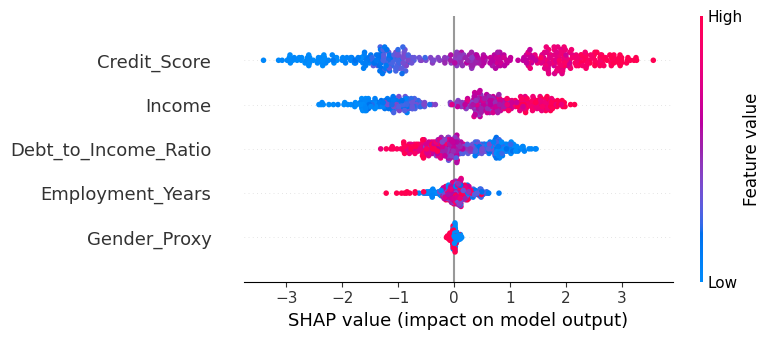

SHAP Waterfall Plot for sample 0:


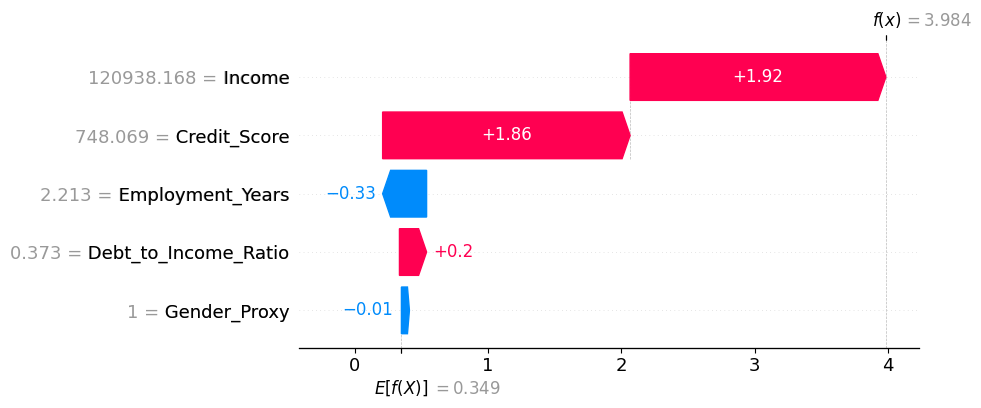

SHAP Dependence Plot for Credit_Score:


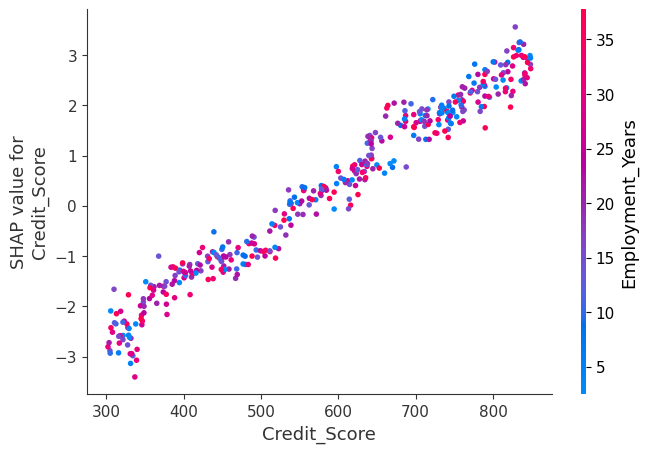

SHAP Dependence Plot for Income:


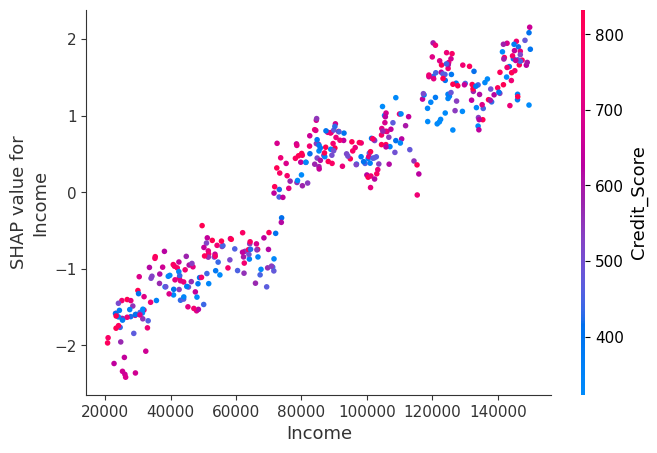

SHAP Dependence Plot for Debt_to_Income_Ratio:


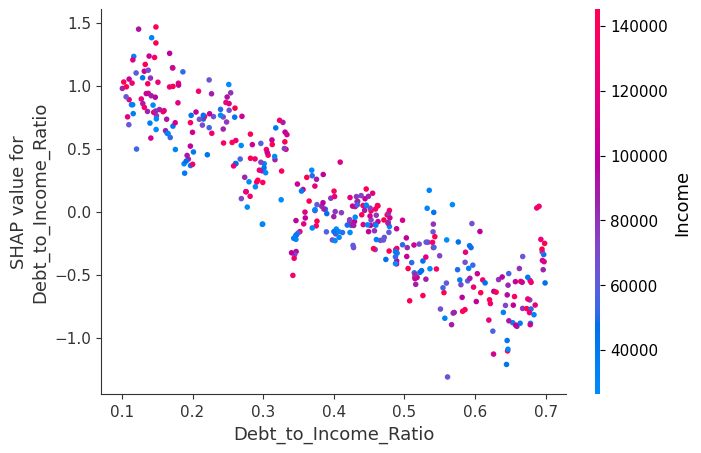

In [9]:

# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot (Beeswarm)
print("SHAP Summary Plot (Beeswarm):")
shap.summary_plot(shap_values, X_test)

# Waterfall plot for the first test sample
print("SHAP Waterfall Plot for sample 0:")
shap.plots.waterfall(explainer(X_test)[0])

# Dependence plots for top 3 features
top_features = importance_df['feature'].head(3).tolist()
for feature in top_features:
    print(f"SHAP Dependence Plot for {feature}:")
    shap.dependence_plot(feature, shap_values, X_test)


## 4. LIME Explanation

Local interpretation for a specific prediction using LIME.

In [10]:

# Create LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=X.columns.tolist(),
    class_names=['Deny', 'Approve'],
    mode='classification'
)

# Explain one instance
instance_idx = 0
exp = lime_explainer.explain_instance(X_test.iloc[instance_idx].values, model.predict_proba, num_features=5)

print(f"LIME explanation for sample {instance_idx}:")
exp.show_in_notebook()


LIME explanation for sample 0:
